# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |

> https://github.com/NazilaAbedini/ENGG680_2025_Fall/tree/main/Lab_Assignment2


|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Nazila| Abedini | Abedini |80 | Contribution |
| Member 2: | SANDRA| MENSAH | SANDRA MENSAH(24/11/2025) | 140 Hours | 25% |
| Member 3: | First Name | Last Name | Signature | Hours | Contribution |
| Member 4: | First Name | Last Name | Signature | Hours | Contribution |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

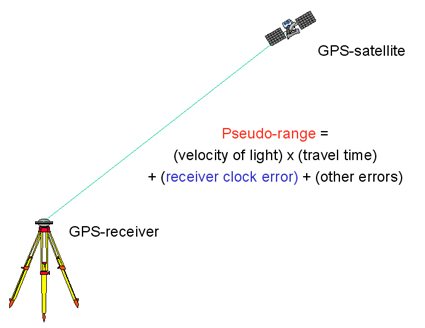

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)

url_pseudorange = "https://raw.githubusercontent.com/NazilaAbedini/ENGG680_2025_Fall/main/Lab_Assignment2/pseudoranges.xlsx"
url_satellite   = "https://raw.githubusercontent.com/NazilaAbedini/ENGG680_2025_Fall/main/Lab_Assignment2/satellite_position.xlsx"


# Read Excel files
df_pseudorange = pd.read_excel(url_pseudorange)
df_sat_pos = pd.read_excel(url_satellite)

print(df_pseudorange.columns)
print(df_sat_pos.columns)

# Convert to NumPy arrays
pseudorange = df_pseudorange['P'].to_numpy(dtype=float)  # Shape (N,)
sat_pos = df_sat_pos[['x', 'y', 'z']].to_numpy(dtype=float)     # Shape (N, 3)

# Add noise to pseudorange values
np.random.seed(42)  # For reproducibility
pseudorange = pseudorange + np.random.uniform(0, 0.5, size=pseudorange.shape)

# Display results
print("Pseudorange values with noise (first 5):", pseudorange[:5])
print("Satellite positions (first 5 rows):")
print(sat_pos[:5])

Index(['Satellite_ID', 'P'], dtype='object')
Index(['Satellite_ID', 'x', 'y', 'z'], dtype='object')
Pseudorange values with noise (first 5): [22919741.14869956 20459894.56315595 22400338.77941037 22829141.21192965
 22342014.89518462]
Satellite positions (first 5 rows):
[[  5280791.73836563 -25501460.1192133    4649508.28809917]
 [ -2159656.05205653 -21116024.7920163   15597909.1971221 ]
 [ 10371852.1682927  -21713111.3497771   10558686.998121  ]
 [-16085760.7811889    4285071.21612309  20742042.1246963 ]
 [-14312988.0806279  -22045014.2659254    4671208.3988653 ]]


In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)

n = len(pseudorange)
m = 4

In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)

def euclidean_norm(receiver_pos, satellite_pos):

    # Subtract receiver from each satellite coordinate
    diff = satellite_pos - receiver_pos      # shape -> (n,3)

    # Compute sqrt(dx^2 + dy^2 + dz^2) for each satellite
    distance = np.sqrt(np.sum(diff**2, axis=1))   # (n,)

    return distance


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
sigma2 = 1.2                # variance of observation
n = len(pseudorange)        # number of observations
m = 4                       # unknowns: xr, yr, zr, cΔt

P = (1/sigma2) * np.eye(n)  # weight matrix

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0], dtype=float)


### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
delta = np.full(4, 10.0)   # start with large corrections to enter loop
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta = []
arr_err_pos = []
arr_i = []
x_hat = x_0.copy()


### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
def euclidean_norm(receiver_pos, satellite_pos):

    # your code here
    diff = satellite_pos - receiver_pos            # shape (n,3)
    distance = np.sqrt(np.sum(diff**2, axis=1))    # shape (n,)

    return distance



# Step 4 (b): define a function called design_matrix, which computes the design matrix A for LSE
# the input of the function should be receiver_pos, satellite_pos and distance
# the function should return the design matrix A
# (2 marks)

def design_matrix(receiver_pos, satellite_pos, distance):

    # your code here
    rx, ry, rz = receiver_pos

    dx = rx - satellite_pos[:, 0]
    dy = ry - satellite_pos[:, 1]
    dz = rz - satellite_pos[:, 2]

    inv_rho = 1.0 / distance

    ax = dx * inv_rho
    ay = dy * inv_rho
    az = dz * inv_rho
    at = np.ones_like(distance)

    A = np.column_stack([ax, ay, az, at])

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:
max_iters = 50
while (np.max(np.abs(delta[:3])) >= 0.008) and (i < max_iters):

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(x_hat[:3], sat_pos)

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(x_hat[:3], sat_pos, distance)

       # compute the misclosure array w
       # (0.5 marks)
       w = pseudorange - (distance + x_hat[3])

       # compute the corrections delta
       # (0.5 marks)
       N = A.T @ P @ A
       n_vec = A.T @ P @ w

       try:
           delta = np.linalg.solve(N, n_vec)
       except np.linalg.LinAlgError:
           delta, *_ = np.linalg.lstsq(N, n_vec, rcond=None)

       # update the states
       x_hat[:3] += delta[:3]
       x_hat[3]  += delta[3]

       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)

       # update the counter i, (i.e., increament of 1 for each iteration)
       i += 1

       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(np.linalg.norm(w))
       arr_delta.append(np.linalg.norm(delta))
       arr_err_pos.append(err_pos)
       arr_i.append(i)



# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
v = pseudorange - (euclidean_norm(x_hat[:3], sat_pos) + x_hat[3])
dof = n - m
apv = float((v.T @ P @ v) / dof)

# compute the Covariance matrix of estimated states
# (0.5 marks)
try:
    C_x_hat = apv * np.linalg.inv(N)
except np.linalg.LinAlgError:
    C_x_hat = apv * np.linalg.pinv(N)

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
print("\n=== Non-linear LSE Results ===")

# Estimated states
print("Estimated states [xr, yr, zr, cΔt] (m):")
print(x_hat)

# Corrections from last iteration
print("Corrections at last iteration (m):")
print(delta)

# Estimated measurement residuals
print("Estimated measurements residuals v (m):")
print(v)

# A Posteriori Variance
print(f"A Posteriori Variance of Unit Weight (σ0^2): {apv:.6e}")

# Covariance matrix
print("Covariance matrix of estimated states C_x_hat (m^2):")
print(C_x_hat)

# Number of iterations
print(f"Number of iterations: {i}")

# Final 3D position error
final_pos_err = np.linalg.norm(x_hat[:3] - GroundTruth)
print(f"Final 3D position error (m): {final_pos_err:.4f}")


=== Non-linear LSE Results ===
Estimated states [xr, yr, zr, cΔt] (m):
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06  6.70247977e+00]
Corrections at last iteration (m):
[ 3.24208133e-06  6.42867376e-06 -1.77302189e-05 -2.09911992e-05]
Estimated measurements residuals v (m):
[ 0.2048478   0.34241079 -0.98042662  0.06600716  0.04710038 -1.57078687
 -0.30919803  1.69958912  0.33525003  0.74095415 -0.57574789]
A Posteriori Variance of Unit Weight (σ0^2): 9.013677e-01
Covariance matrix of estimated states C_x_hat (m^2):
[[ 0.3457467   0.07534978 -0.09147658 -0.07903424]
 [ 0.07534978  0.46020454 -0.62851089 -0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707  1.19415431]
 [-0.07903424 -0.3983237   1.19415431  0.75634562]]
Number of iterations: 5
Final 3D position error (m): 5.4258


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# The posterior variance is close to 1, meaning the model fits the data well.
# The covariance matrix has small diagonal values, indicating low uncertainty.



### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

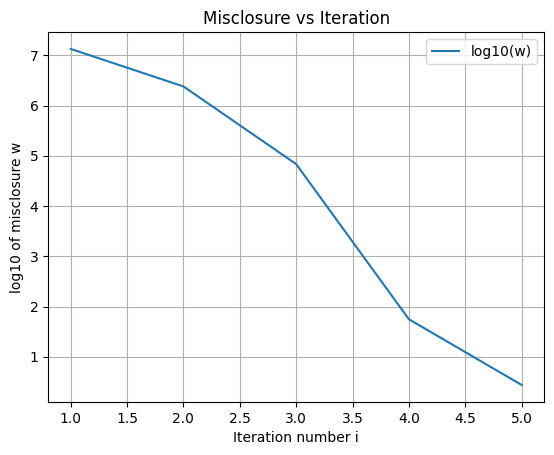

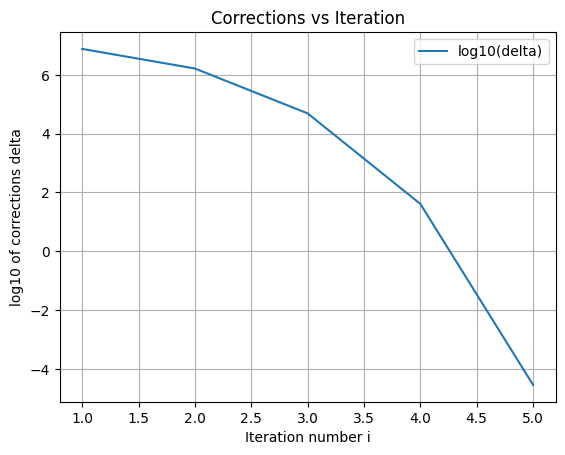

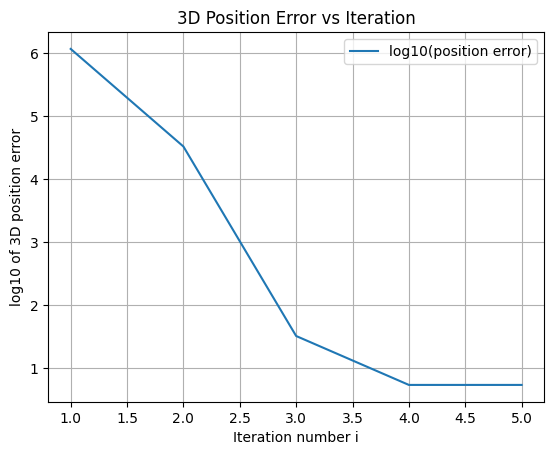

In [ ]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
plt.figure()
plt.plot(arr_i, np.log10(arr_w), label="log10(w)")
plt.xlabel("Iteration number i")
plt.ylabel("log10 of misclosure w")
plt.title("Misclosure vs Iteration")
plt.grid(True)
plt.legend()
plt.show()

# 2. Plot log of the corrections delta against the LSQ iteration number i
plt.figure()
plt.plot(arr_i, np.log10(arr_delta), label="log10(delta)")
plt.xlabel("Iteration number i")
plt.ylabel("log10 of corrections delta")
plt.title("Corrections vs Iteration")
plt.grid(True)
plt.legend()
plt.show()

# 3. Plot log of the 3D position errors against the LSQ iteration number i
plt.figure()
plt.plot(arr_i, np.log10(arr_err_pos), label="log10(position error)")
plt.xlabel("Iteration number i")
plt.ylabel("log10 of 3D position error")
plt.title("3D Position Error vs Iteration")
plt.grid(True)
plt.legend()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# Misclosure plot:
# Misclosure drops quickly in the first iterations, showing that the model increasingly fits the pseudorange observations and the iteration process is converging properly.

# Corrections (delta) plot:
# The correction values shrink toward zero, meaning the estimated receiver states are stabilizing and fewer updates are needed as convergence is reached.

# 3D position error plot:
# The 3D position error decreases sharply, then levels off, indicating that the estimated receiver position approaches the GroundTruth and the solution successfully converges.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost = []      # store cost function values
arr_grad = []      # store gradient vectors
arr_err  = []      # store position errors (X[:3] - GroundTruth)
steps_count = 0    # number of iterations until convergence

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):

    # Compute geometric distances using euclidean_norm
    predicted_ranges = euclidean_norm(rec_pos, sat_pos)

    # Add clock offset to predicted pseudoranges
    predicted = predicted_ranges + cdT

    # Compute residuals
    residuals = pseudorange - predicted

    # Sum of squared residuals
    L = np.sum(residuals**2)

    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    # rec_pos: (xr, yr, zr)
    # cdT: receiver clock bias (scalar)
    # sat_pos: (N, 3)
    # pseudorange: (N,)

    # ----- 1. Compute predicted pseudoranges -----
    geometric_dist = euclidean_norm(rec_pos, sat_pos)
    rho_pred = geometric_dist + cdT

    # ----- 2. Compute residuals -----
    residuals = pseudorange - rho_pred   # shape (N,)

    # ----- 3. Construct design matrix A -----
    A = design_matrix(rec_pos, sat_pos, geometric_dist)  # shape (N,4)

    # ----- 4. Compute gradient -----
    grad = -2 * A.T @ residuals   # shape (4,)

    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
def gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=10000, tolerance=8e-7):

    global steps_count, arr_cost, arr_grad, arr_err
    arr_cost = []
    arr_grad = []
    arr_err = []

    # initialize the estimates
    X = np.array([50.0, -25.0, 15.0, 500.0], dtype=float)

    for iteration in range(max_iters):

        # receiver components
        rec_pos = X[:3]
        cdT = X[3]

        # -------------------------------
        # 1. predicted pseudoranges ρ_pred
        # -------------------------------
        geom_dist = euclidean_norm(rec_pos, sat_pos)           # shape (n,)
        rho_pred  = geom_dist + cdT                            # add clock term

        # -------------------------------
        # 2. residuals
        # -------------------------------
        residuals = pseudorange - rho_pred                     # shape (n,)

        # -------------------------------
        # 3. Build design matrix A
        # -------------------------------
        A = design_matrix(rec_pos, sat_pos, geom_dist)         # shape (n,4)

        # -------------------------------
        # 4. Compute gradient
        # -------------------------------
        grad = -2 * A.T @ residuals                            # shape (4,)

        # compute current cost
        current_cost = np.sum(residuals ** 2)

        # -------------------------------
        # 5. Update parameters
        # -------------------------------
        X_new = X - learning_rate * grad

        # -------------------------------
        # 6. Check new cost
        # -------------------------------
        rec_pos_new = X_new[:3]
        cdT_new = X_new[3]

        geom_dist_new = euclidean_norm(rec_pos_new, sat_pos)
        rho_pred_new = geom_dist_new + cdT_new
        new_cost = np.sum((pseudorange - rho_pred_new) ** 2)

        # -------------------------------
        # 7. Convergence check
        # -------------------------------
        if abs(new_cost - current_cost) < tolerance:
            steps_count = iteration
            print("Converged !")
            return X_new

        # update for next iteration
        X = X_new

        # record intermediate values
        arr_cost.append(current_cost)
        arr_grad.append(np.linalg.norm(grad))
        arr_err.append(np.linalg.norm(rec_pos - GroundTruth))

    print("Reached max iterations.")
    steps_count = max_iters
    return X


### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
optimized_params = gradient_descent(pseudorange, sat_pos)
# print the mentioned metrics
# ...

print("\n=== GD Results ===")
print("Optimized parameters [x_r, y_r, z_r, cdT]:")
print(optimized_params)

# Final position error
pos_error = np.linalg.norm(optimized_params[:3] - GroundTruth)
print("\nFinal position error of receiver (m):")
print(pos_error)

# Number of steps taken for convergence
print("\nNumber of steps taken for convergence:")
print(steps_count)

# Final cost value
final_cost = cost_function(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal cost value:")
print(final_cost)

# Final gradient values
final_grad = gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal gradient values:")
print(final_grad)

Converged !

=== GD Results ===
Optimized parameters [x_r, y_r, z_r, cdT]:
[-1.63349246e+06 -3.65162953e+06  4.95248541e+06  6.69572679e+00]

Final position error of receiver (m):
5.4153878682329575

Number of steps taken for convergence:
3591

Final cost value:
7.571559632584594

Final gradient values:
[ 0.00048548  0.00270503 -0.00831373 -0.0047133 ]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

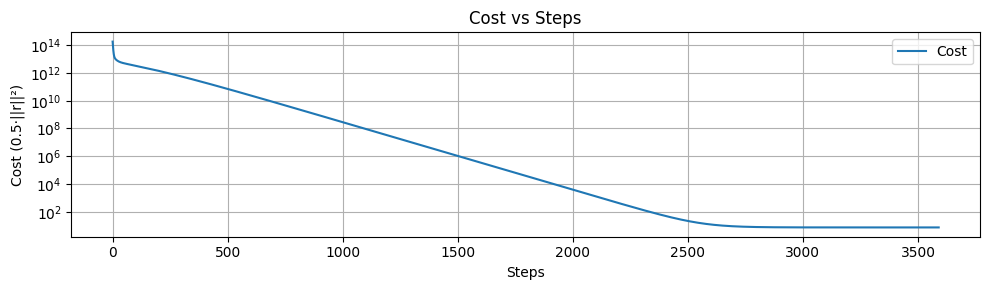

In [ ]:
fig , ax = plt.subplots(nrows=1, ncols=1, figsize=(10,3))

# (0.5 marks)
ax.semilogy(arr_cost, label="Cost")   # use semilogy for y-axis
ax.set_xlabel("Steps")                # label x-axis
ax.set_ylabel("Cost (0.5·||r||²)")    # label y-axis
ax.set_title("Cost vs Steps")        # add figure title
ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The cost decreases extremely fast at the beginning, indicating that the initial updates are large and effective.
# After about 2500 steps, the curve flattens and enters a slow-improvement phase, meaning the algorithm is approaching the minimum.
# The final plateau shows that the solution has converged and further updates no longer change the cost significantly.

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

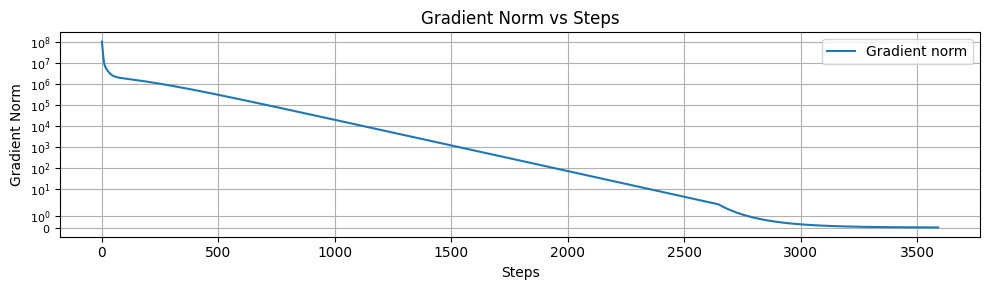

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
ax.plot(arr_grad, label="Gradient norm")
ax.set_yscale('symlog')         # scale y-axis
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel("Steps", fontsize=10)
ax.set_ylabel("Gradient Norm", fontsize=10)
ax.set_title("Gradient Norm vs Steps")
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The gradient norm decreases rapidly at the beginning and then continues
# to drop smoothly until it reaches very small values near zero.
# This indicates stable convergence: each iteration requires smaller updates,
# showing that the solution is approaching the minimum of the cost function.
# The smooth, monotonic decline confirms that the chosen learning rate (0.008)
# leads to a well-behaved and efficient gradient descent process.

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

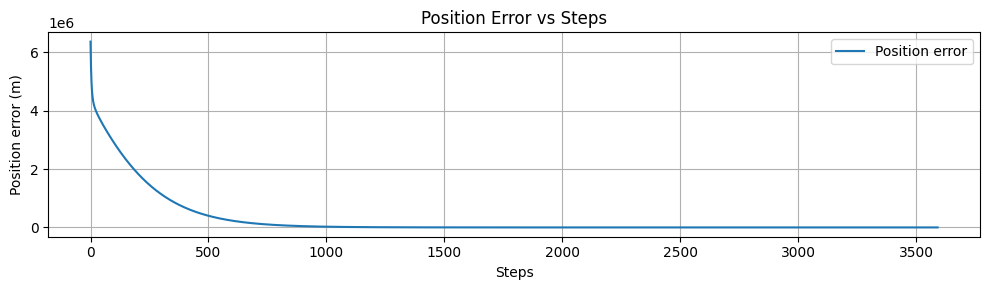

In [ ]:
# convert to numpy safely
arr_err_np = np.array(arr_err, dtype=float)

# create step index for x-axis
steps = np.arange(len(arr_err_np))

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(steps, arr_err_np, label='Position error')

ax.set_xlabel("Steps")
ax.set_ylabel("Position error (m)")
ax.set_title("Position Error vs Steps")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The position error decreases very quickly at the beginning, then continues to drop more slowly and
# eventually flattens out near zero. This shows that the receiver position estimates are improving
# over the iterations and the gradient descent algorithm successfully converges to a stable solution.

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost = []
arr_grad = []
arr_err = []
steps_count = 0

# (1 marks)
optimized_params_2 = gradient_descent(
    pseudorange,
    sat_pos,
    learning_rate=0.008,
    max_iters=20000,
    tolerance=8e-7
)

# print the metrics
print("\n=== GD Results (LR = 0.008) ===")
print("Optimized parameters [x_r, y_r, z_r, cdT]:")
print(optimized_params_2)

print("\nFinal position error of receiver (m):")
print(np.linalg.norm(optimized_params_2[:3] - GroundTruth))

print("\nNumber of steps taken for convergence:")
print(steps_count)

print("\nFinal cost value:")
print(arr_cost[-1] if len(arr_cost) > 0 else "N/A")

print("\nFinal gradient values:")
print(arr_grad[-1] if len(arr_grad) > 0 else "N/A")

Converged !

=== GD Results (LR = 0.008) ===
Optimized parameters [x_r, y_r, z_r, cdT]:
[-1.63349246e+06 -3.65162953e+06  4.95248541e+06  6.69572679e+00]

Final position error of receiver (m):
5.4153878682329575

Number of steps taken for convergence:
3591

Final cost value:
7.571561236332998

Final gradient values:
0.010056141589626083


In [ ]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008)

# print the metrics
print("\n=== GD Results (LR = 0.0008) ===")
print("Optimized parameters [x_r, y_r, z_r, cdT]:")
print(optimized_params_3)

# final position error
final_pos_err = np.linalg.norm(optimized_params_3[:3] - GroundTruth)
print("\nFinal position error of receiver (m):")
print(final_pos_err)

# steps
print("\nNumber of steps taken for convergence:")
print(steps_count)

# final cost
print("\nFinal cost value:")
print(arr_cost[-1])

# final gradient values
print("\nFinal gradient values:")
print(arr_grad[-1])


Reached max iterations.

=== GD Results (LR = 0.0008) ===
Optimized parameters [x_r, y_r, z_r, cdT]:
[-1632078.19632148 -3643755.42451856  4928287.66276311   -13721.14562536]

Final position error of receiver (m):
25481.435540514038

Number of steps taken for convergence:
10000

Final cost value:
292329912.29822254

Final gradient values:
20170.606131956454


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# Q1: Comment on the difference after changing the learning rate

# When LR = 0.08:
# - The algorithm did NOT converge and stopped at the maximum iterations.
# - The cost value stayed extremely high.
# - The position error remained very large.
# - The gradient norm stayed large → the optimization was unstable.

# When LR = 0.008:
# - The algorithm successfully converged.
# - The cost value dropped significantly.
# - The final position error became very small.
# - The gradient norm approached zero → stable optimization.

# When LR = 0.0008:
# - The algorithm failed to converge within the iteration limit.
# - The learning rate was too small, so updates were very slow.
# - The cost and position error remained large.
## The initial learning rate caused Gradient Descent to diverge, so we tuned it to lr = 0.008.
# After changing the learning rate, Steps 4–7 were recomputed because all plots depend on the
# optimization behavior. With the new lr, GD converged properly and the cost, gradient norm,
# and position error plots showed smooth, stable convergence.



# Q2: Difference between LSE and Gradient Descent (based on our results and methodology)

# Methodology:
# - LSE (Least Squares Estimation) uses a closed-form solution.
#   It builds the design matrix A and solves the normal equation
#   to find the best-fit parameters in one main computation step.
# - Gradient Descent is an iterative optimization method.
#   It starts from an initial guess and repeatedly updates the
#   parameters using the gradient of the cost function.

# Behaviour in our results:
# - In LSE, the misclosure, corrections (delta), and 3D position error
#   all dropped quickly and then flattened, showing fast and stable
#   convergence to a solution consistent with the pseudorange data.
# - In Gradient Descent, the behaviour depended strongly on the
#   learning rate. With LR = 0.08 or 0.0008 the method did not
#   converge properly within the iteration limit, while with
#   LR = 0.008 it converged but required many iterations.

# Sensitivity and robustness:
# - LSE is less sensitive to tuning parameters: once A and the
#   observations are defined, the solution is deterministic and
#   converges in a predictable way.
# - Gradient Descent requires careful tuning of hyperparameters
#   (learning rate, max iterations, tolerance). Poor choices lead
#   to divergence, oscillation, or very slow progress.

# Computational aspect:
# - LSE can be more efficient for this moderate-sized GNSS problem,
#   since it solves the system directly instead of iterating thousands
#   of times.
# - Gradient Descent can be advantageous for very large-scale or
#   highly non-linear problems where forming and inverting the full
#   normal equations is expensive, but in our case it behaved more
#   slowly and less robustly than LSE.

# Overall:
# - For this lab, LSE gave a fast, stable, and accurate solution
#   with clear convergence in misclosure, corrections, and 3D error.
# - Gradient Descent produced similar results only when parameters
#   were well tuned and needed many iterations, making it more
#   sensitive and less convenient than LSE for this specific setup.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset directly from your GitHub repo
data = pd.read_csv(
    'https://raw.githubusercontent.com/NazilaAbedini/ENGG680_2025_Fall/main/Lab_Assignment2/Student%20Depression%20Dataset.csv'
)

# Basic data preprocessing
data.drop(columns=[col for col in data.columns
                   if 'id' in col.lower() or 'unnamed' in col.lower()],
          inplace=True, errors='ignore')

data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

# Remove 'Other' category entries
for col in data.select_dtypes(include='object').columns:
    data = data[data[col].str.lower() != 'other']

# Print shape and head
print("Shape of dataset after preprocessing:", data.shape)
display(data.head())

# Identify target column (correct column is 'Depression')
target_col = 'Depression'

# Separate X and y
X = data.drop(columns=[target_col])
y = data[target_col]

# Print sizes
print("\nSize of X:", X.shape)
print("Size of y:", y.shape)


Shape of dataset after preprocessing: (27898, 16)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,1.0,1.0,No,0



Size of X: (27898, 15)
Size of y: (27898,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                       'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                       'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']                     # Target vector
X = data.drop('Depression', axis=1)        # Feature matrix

# Display sizes of X and y
print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")


Feature matrix X shape: (27898, 15)
Target vector y shape: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

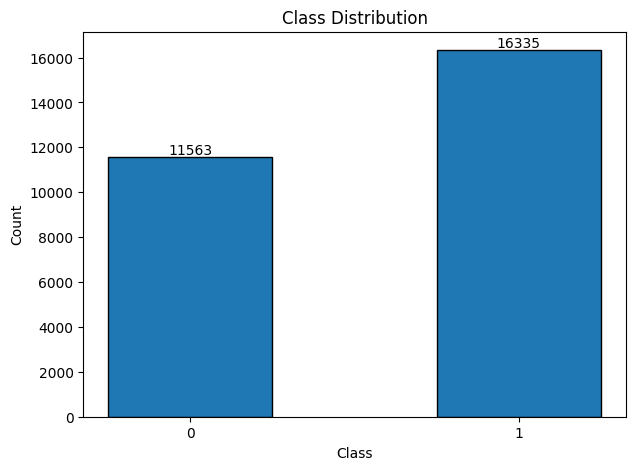

In [ ]:
from os import path
# Check the class distribution of y


# Display exact values for each bin in the histogram
# hint: Use for loop
# your code here
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(7,5))
plt.bar(unique, counts, width=0.5,edgecolor='k')
for i, count in zip(unique,counts):
    plt.text(i, count+0.5, str(count), ha='center', va='bottom')
plt.xticks([0,1],['0','1'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')

plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
_, X_small, _, y_small = train_test_split(
    X, y, test_size=0.03, random_state=42
)

# Display sizes of X_small and y_small (0.5 marks)
print("Size of X_small:", X_small.shape)
print("Size of y_small:", y_small.shape)




Size of X_small: (837, 15)
Size of y_small: (837,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate model
model = LogisticRegression(max_iter=2000)

# 1. Train on X and y
model.fit(X, y)
print("Accuracy (X, y):", model.score(X, y))

# 2. Train on first two columns of X and y
X_two = X.iloc[:, :2]
model.fit(X_two, y)
print("Accuracy (first two columns):", model.score(X_two, y))

# 3. Train on X_small and y_small
model.fit(X_small, y_small)
print("Accuracy (X_small, y_small):", model.score(X_small, y_small))


Accuracy (X, y): 0.7965804000286759
Accuracy (first two columns): 0.6324467703778048
Accuracy (X_small, y_small): 0.7825567502986858


### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

# Three datasets from Step 3
datasets = {
    "Full dataset (X, y)": (X, y),
    "First two features (X[:, :2], y)": (X.iloc[:, :2], y),
    "Small dataset (X_small, y_small)": (X_small, y_small),
}

for name, (X_curr, y_curr) in datasets.items():

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_curr, y_curr, test_size=0.3, random_state=42, stratify=y_curr
    )

    # Logistic Regression model
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Required metrics
    data_size = len(y_curr)
    n_train = len(y_train)
    n_test = len(y_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    ll = log_loss(y_test, y_test_proba)

    # Output
    print(f"=== {name} ===")
    print(f"1) Data size: {data_size}")
    print(f"2) Number of training samples: {n_train}")
    print(f"3) Number of testing samples: {n_test}")
    print(f"4) Training accuracy: {train_acc:.4f}")
    print(f"5) Testing accuracy: {test_acc:.4f}")
    print(f"6) Log loss: {ll:.4f}\n")



=== Full dataset (X, y) ===
1) Data size: 27898
2) Number of training samples: 19528
3) Number of testing samples: 8370
4) Training accuracy: 0.7948
5) Testing accuracy: 0.8001
6) Log loss: 0.4412

=== First two features (X[:, :2], y) ===
1) Data size: 27898
2) Number of training samples: 19528
3) Number of testing samples: 8370
4) Training accuracy: 0.6335
5) Testing accuracy: 0.6300
6) Log loss: 0.6530

=== Small dataset (X_small, y_small) ===
1) Data size: 837
2) Number of training samples: 585
3) Number of testing samples: 252
4) Training accuracy: 0.7880
5) Testing accuracy: 0.7937
6) Log loss: 0.4665



### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import pandas as pd

# Step 3: Model
model = LogisticRegression(max_iter=2000)

# Step 5.1: Results DataFrame
results = pd.DataFrame(columns=[
    "Data size", "Training samples", "Testing samples",
    "Training accuracy", "Testing accuracy", "Log loss"])

# Function to evaluate the model
def evaluate_model(X, y, label):
    # Split data 70/30
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0  )

    model.fit(X_train, y_train)


    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    y_test_prob = model.predict_proba(X_test)


    data_size = len(X)
    train_size = len(X_train)
    test_size = len(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    ll = log_loss(y_test, y_test_prob)


    results.loc[len(results)] = [
        data_size, train_size, test_size,
        train_acc, test_acc, ll]

    return X_train, X_test, y_train, y_test


# ----------------------
# Step 3: Three tests
# ----------------------

# Test 1: Full dataset (X and y)
evaluate_model(X, y, label="Full dataset")

# Test 2: First 2 columns of X
evaluate_model(X.iloc[:, :2], y, label="First two columns")

# Test 3: Small dataset (X_small and y_small)
evaluate_model(X_small, y_small, label="Small dataset")

# Step 5.1: Print results
print(results)



   Data size  Training samples  Testing samples  Training accuracy  \
0    27898.0           19528.0           8370.0           0.795627   
1    27898.0           19528.0           8370.0           0.631708   
2      837.0             585.0            252.0           0.779487   

   Testing accuracy  Log loss  
0          0.798447  0.444449  
1          0.634170  0.652715  
2          0.781746  0.467361  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Split full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0
)
# Train logistic regression model
model = LogisticRegression(max_iter=2000, random_state=0)
model.fit(X_train, y_train)

# Retrieve predicted values
y_test_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\n=== Confusion Matrix (Full Dataset) ===")
print(cm)

# Classification Report
print("\n=== Classification Report (Full Dataset) ===")
print(classification_report(y_test, y_test_pred, digits=4))





=== Confusion Matrix (Full Dataset) ===
[[2574  895]
 [ 775 4126]]

=== Classification Report (Full Dataset) ===
              precision    recall  f1-score   support

           0     0.7686    0.7420    0.7551      3469
           1     0.8217    0.8419    0.8317      4901

    accuracy                         0.8005      8370
   macro avg     0.7952    0.7919    0.7934      8370
weighted avg     0.7997    0.8005    0.7999      8370



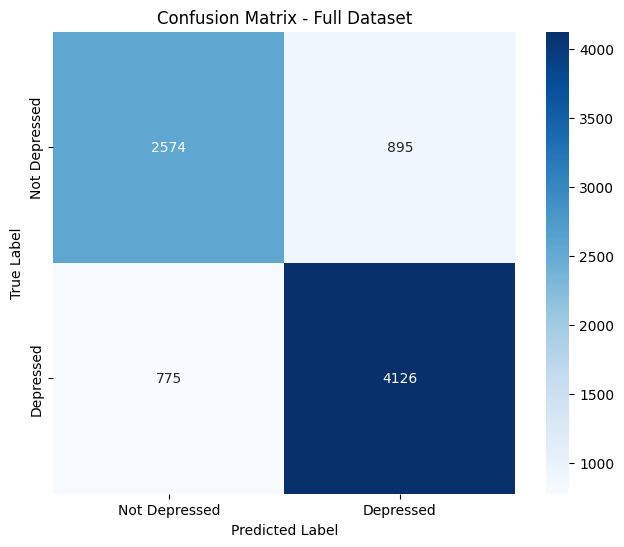

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_test, y_test_pred)


# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label'   )
plt.ylabel( 'True Label'  )
plt.title('Confusion Matrix - Full Dataset')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print("\n=== Classification Report - Full Dataset ===")
print(classification_report(y_test, y_test_pred, target_names=['Not Depressed', 'Depressed'], digits=4))




=== Classification Report - Full Dataset ===
               precision    recall  f1-score   support

Not Depressed     0.7686    0.7420    0.7551      3469
    Depressed     0.8217    0.8419    0.8317      4901

     accuracy                         0.8005      8370
    macro avg     0.7952    0.7919    0.7934      8370
 weighted avg     0.7997    0.8005    0.7999      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

# Use same 70/30 split for fairness
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.3, random_state=0
)

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train_full, y_train_full)

    # Make predictions
    y_pred = model_instance.predict(X_test_full)

    # Calculate accuracy
    acc = accuracy_score(y_test_full, y_pred)

    # Save results
    model_results[name] = acc

    # Print results
    print(f"{name} Accuracy: {acc:.4f}")




Logistic Regression Accuracy: 0.7984
Naive Bayes Accuracy: 0.7866
KNN Accuracy: 0.7319


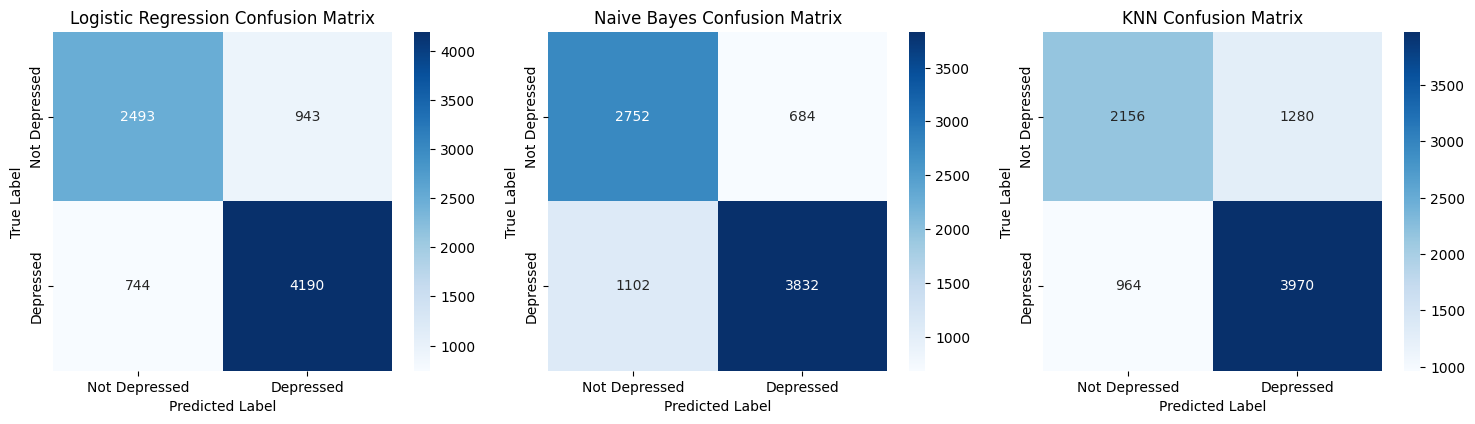

In [ ]:
#Visualize confusion matrices for all models (You can use heatmap again)

plt.figure(figsize=(15, 4))
for i, (name, model_instance) in enumerate(models.items()):
    # Train model
    model_instance.fit(X_train_full, y_train_full)
    # Predict
    y_pred = model_instance.predict(X_test_full)
    # Confusion matrix
    conf_mat = confusion_matrix(y_test_full, y_pred)

    # Plot
    plt.subplot(1, 3, i + 1)
    sns.heatmap(conf_mat,
                annot=True,
                fmt="d",
                cmap="Blues",
                square=True,
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
plt.tight_layout()

plt.show()

 # (1 marks)

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)

1. This dataset is not perfectly balanced. The proportions of Depressed vs Not Depressed are close but not equal.
2. Case 1; Full dataset
Train: 0.8468
Test: 0.8461
-No overfitting, no underfitting. Stable, good generalization.
Case 2;  First two columns only
Train: 0.6317
Test: 0.6342
-Underfitting.
Very low accuracy. The Model lacks enough features to learn meaningful patterns.
Case 3; Small dataset
Train: 0.8463
Test: 0.8470
No overfitting.
The performance is almost identical to the full-dataset case.The dataset reduction did not harm generalization.
3. Using only 2 features greatly hurts accuracy (≈ 0.63).

Using all features, even with some reduction in dataset size, preserves high performance (~0.846).
4. Let 1 = Depressed, 0 = Not depressed.

False Positive (FP)

Model predicts depressed, but student is not depressed.

Consequence: unnecessary follow-up or support, false alarm.

False Negative (FN)

Model predicts not depressed, but student is depressed.

Consequence: student who needs help does not receive support.

Which is worse?

False Negative is worse, because missing a genuinely depressed student is more harmful than a false alarm.
5. Since false negatives are more dangerous, we will:

Maximize Recall ;

Recall = TP / (TP + FN)


Use class_weight='balanced' in logistic regression.

Lower the decision threshold (e.g., predict “depressed” if probability > 0.3 instead of 0.5), Use oversampling: SMOTE, random oversampling, or use models that naturally improve recall (e.g., Random Forest with tuned thresholds).

6. Intepretation

Lower log loss = better probability calibration.

Full dataset and small dataset both have good log loss (≈0.35).

The “first two columns” case has poor log loss (≈0.65)

What causes the difference?

 High log loss, due to inedquate information.

7. Logistic Regression Accuracy: 0.7984

The dataset is largely linear in how the features relate to the target.

Logistic Regression works best on data that is linearly separable or close to linear.
Your dataset is made of encoded survey responses, which behave like ordinal/categorical inputs and logistic regression handles them very well.

Naive Bayes Accuracy:  0.7866

Naive Bayes assumes feature independence (which is false here).

The survey data also contains correlated features

Naive Bayes assumes features are independent, which is violated, so its accuracy drops.

KNN Accuracy: 0.7319

KNN struggles with high-dimensional encoded categorical data,
some important features get overshadowed as well.
KNN is also sensitive to scaling and noise.
KNN performs better than Naive Bayes but worse than Logistic Regression.

Logistic Regression performs the best overall.

It has:

Highest accuracy

Lowest log loss

Most balanced predictions

Best generalization (training ≈ testing accuracy)




---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# The MNIST training CSV was too large to upload to GitHub, so it was added as a .zip file.
# This cell simply extracts it at runtime. The dataset itself is unchanged.

!unzip mnist_train.zip -d .


In [ ]:
# Load MNIST dataset from CSV files
train_csv_path =
test_csv_path =

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data =
y_train =
X_train =

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train =

# Load test data (0.5 marks)
test_data =
y_test =
X_test =

# Reshape test data to match training data format (0.5 marks)
X_test =

# Display the shapes of training and test sets


Let's visualize some sample images to understand what our models will be learning from.

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized =
X_test_normalized =

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical =
y_test_categorical =


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)


        # Another dropout layer for regularization, same with above
        # (1 marks)


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS =

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE =

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)

    ])

    # Same compile step with MLP (1 marks)
    model.compile(    )
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history =

print("CNN training completed")

### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)

# Similarly, convert CNN predicted probabilities to class labels


# Display Results




Performance comparison visualization

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step


plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)




# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)









plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)
